# Analyse Exploratoire

### Import des modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 30) 

### Analyse Exploratoire

In [2]:
building_consumption = pd.read_csv("data/2016_Building_Energy_Benchmarking.csv")

In [3]:
# On regarde comment un batiment est défini dans ce jeu de données 
print(building_consumption.shape)
building_consumption.head(10)

(3376, 46)


,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2.003882e+06,1.156514e+06,3946027.0,12764.529300,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.000000e+00,9.504252e+05,3242851.0,51450.816410,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,2.156655e+07,1.451544e+07,49526664.0,14938.000000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2.214446e+06,8.115253e+05,2768924.0,18112.130860,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.000000e+00,1.573449e+06,5368607.0,88039.984380,8803998.0,False,NaN,Compliant,NaN,505.01,2.88
5,9,2016,Nonresidential COS,Other,West Precinct,810 Virginia St,Seattle,WA,98101.0,0660000560,7,DOWNTOWN,47.61623,-122.33657,1999,1.0,2,97288,37198,60090,Police Station,Police Station,88830.0,NaN,NaN,NaN,NaN,NaN,NaN,136.100006,141.600006,316.299988,320.500000,12086616.0,12581712.0,0.000000e+00,2.160444e+06,7371434.0,47151.816410,4715182.0,False,NaN,Compliant,NaN,301.81,3.10
6,10,2016,NonResidential,Hotel,Camlin,1619 9th Avenue,Seattle,WA,98101.0,0660000825,7,DOWNTOWN,47.61390,-122.33283,1926,1.0,11,83008,0,83008,Hotel,Hotel,81352.0,NaN,NaN,NaN,NaN,NaN,27.0,70.800003,74.500000,146.600006,154.699997,5758795.0,6062767.5,0.000000e+00,8.239199e+05,2811215.0,29475.800780,2947580.0,False,NaN,Compliant,NaN,176.14,2.12
7,11,2016,NonResidential,Other,Paramount Theatre,911 Pine St,Seattle,WA,98101.0,0660000955,7,DOWNTOWN,47.61327,-122.33136,1926,1.0,8,102761,0,102761,Other - Entertainment/Public Assembly,Other - Entertainment/Public Assembly,102761.0,NaN,NaN,NaN,NaN,NaN,NaN,61.299999,68.800003,141.699997,152.300003,6298131.5,7067881.5,2.276286e+06,1.065843e+06,3636655.0,3851.890137,385189.0,False,NaN,Compliant,NaN,221.51,2.16
8,12,2016,NonResidential,Hotel,311wh-Pioneer Square,612 2nd Ave,Seattle,WA,98104.0,0939000080,7,DOWNTOWN,47.60294,-122.33263,1904,1.0,15,163984,0,163984,Hotel,Hotel,163984.0,Na

In [4]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
building_consumption.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

#### TERMINER L'ANALYSE EXPLORATOIRE 

A réaliser : 
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

## Premier nettoyage (sur colonne BuildingType) et changement des types

### Changement de type

In [5]:
# Changement du type de la colonne ZipCode (actuellement float) c'est simplement pour avoir des chiffres ronds
# building_consumption['ZipCode'] = building_consumption['ZipCode'].apply(lambda x: str(int(x)) if pd.notna(x) else None)
building_consumption['ZipCode'] = building_consumption['ZipCode'].round().astype('Int64')
building_consumption['ZipCode'].head()

0    98101
1    98101
2    98101
3    98101
4    98121
Name: ZipCode, dtype: Int64

In [6]:
# Changement du type de la colonne NumberofBuildings (actuellement float) c'est simplement pour avoir des chiffres ronds
# building_consumption['NumberofBuildings'] = building_consumption['NumberofBuildings'].apply(lambda x: str(int(x)) if pd.notna(x) else None)
building_consumption['NumberofBuildings'] = building_consumption['NumberofBuildings'].round().astype('Int64')
building_consumption['NumberofBuildings'].head()

0    1
1    1
2    1
3    1
4    1
Name: NumberofBuildings, dtype: Int64

In [7]:
# # Changement du type de la colonne LargestPropertyUseTypeGFA (actuellement float) c'est simplement pour avoir des chiffres ronds
# building_consumption['LargestPropertyUseTypeGFA'] = building_consumption['LargestPropertyUseTypeGFA'].apply(lambda x: str(int(x)) if pd.notna(x) else None)
building_consumption['LargestPropertyUseTypeGFA'] = building_consumption['LargestPropertyUseTypeGFA'].round().astype('Int64')
building_consumption['LargestPropertyUseTypeGFA'].head()


0     88434
1     83880
2    756493
3     61320
4    123445
Name: LargestPropertyUseTypeGFA, dtype: Int64

### Control des colonnes primaires 

In [8]:
# Check pour voir si il y a des doublons dans la colonne OSEBuildingID
building_consumption['OSEBuildingID'].duplicated().sum()

np.int64(0)

In [9]:
# Check pour voir si il y a des valeurs bizarre dans les colonnes primaires
print(building_consumption['City'].value_counts(dropna=False))
print(building_consumption['State'].value_counts(dropna=False))
print(building_consumption['Outlier'].value_counts(dropna=False))
print(building_consumption['Comments'].value_counts(dropna=False))

City
Seattle    3376
Name: count, dtype: int64
State
WA    3376
Name: count, dtype: int64
Outlier
NaN             3344
Low outlier       23
High outlier       9
Name: count, dtype: int64
Comments
NaN    3376
Name: count, dtype: int64


### Premier nettoyage 

In [10]:
building_consumption['BuildingType'].value_counts(dropna=False)
# NonResidential : 1460 bâtiments étiquetés NonResidential = A garder 
# Multifamily LR (1-4) : 1018 bâtiments de type Multifamily Low Rise (1 à 4 étages) = Ne pas garder
# Multifamily MR (5-9) : 580 bâtiments multifamiliaux Medium Rise (5 à 9 étages) = Ne pas garder
# Multifamily HR (10+) : 110 bâtiments multifamiliaux High Rise (10 étages ou plus) = Ne pas garder
# SPS-District K-12 : 98 écoles primaires/secondaires = A garder
# Nonresidential COS : 85 bâtiments non résidentiels (City of Seattle aparement) = A garder
# Campus : 24 campus (probablement universités) = Je ne sais pas si il est possible de dormir dedans
# Nonresidential WA : 1 seul bâtiment (Washington state aparement) = A garder

BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64

In [11]:
buildingtype_to_keep = ['NonResidential', 'SPS-District K-12', 'Nonresidential COS', 'Campus', 'Nonresidential WA']
df_premier_nettoyage = building_consumption[building_consumption['BuildingType'].isin(buildingtype_to_keep)]
print(df_premier_nettoyage.shape)
df_premier_nettoyage['BuildingType'].value_counts(dropna=False)

(1668, 46)


BuildingType
NonResidential        1460
SPS-District K-12       98
Nonresidential COS      85
Campus                  24
Nonresidential WA        1
Name: count, dtype: int64

## Deuxieme nettoyage (sur PrimaryPropertyType)

In [12]:
primarypropoertytype_not_to_keep = ['Residence Hall', 'Senior Care Community', 'Low-Rise Multifamily']
df_deuxieme_nettoyage = df_premier_nettoyage[~df_premier_nettoyage['PrimaryPropertyType'].isin(primarypropoertytype_not_to_keep)]
print(df_deuxieme_nettoyage.shape)
df_deuxieme_nettoyage['PrimaryPropertyType'].value_counts(dropna=False)

(1624, 46)


PrimaryPropertyType
Small- and Mid-Sized Office    292
Other                          250
Warehouse                      187
Large Office                   173
K-12 School                    139
Mixed Use Property             114
Retail Store                    91
Hotel                           76
Worship Facility                71
Distribution Center             53
Supermarket / Grocery Store     40
Medical Office                  39
Self-Storage Facility           28
University                      24
Refrigerated Warehouse          12
Restaurant                      12
Hospital                        10
Laboratory                      10
Office                           3
Name: count, dtype: int64

## Troisieme nettoyage (retrait des colonnes vides et inutiles pour l'étude)

In [13]:
def identifier_les_colonnes_entierement_vide(df):
    empty_cols = df.columns[df.isna().all()]
    if len(empty_cols) == 0:
        print("aucune colonne entièrement vide")
    else:
        print('colonne entièrement vide :')
        for col in empty_cols:
            print(f'- {col}')

In [14]:
identifier_les_colonnes_entierement_vide(df_deuxieme_nettoyage)

colonne entièrement vide :
- Comments


In [15]:
df_troisieme_nettoyage = df_deuxieme_nettoyage.drop(columns=['DataYear', 'PropertyName', 'Address', 'City', 'State', 'Latitude', 
                                                             'Longitude', 'TaxParcelIdentificationNumber', 'Comments', 'DefaultData', 'Outlier'])
df_troisieme_nettoyage.reset_index(inplace=True, drop=True)
print(df_troisieme_nettoyage.shape)
df_troisieme_nettoyage

(1624, 35)


,OSEBuildingID,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
0,1,NonResidential,Hotel,98101,7,DOWNTOWN,1927,1,12,88434,0,88434,Hotel,Hotel,88434,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7.226362e+06,7.456910e+06,2003882.00,1.156514e+06,3.946027e+06,12764.529300,1.276453e+06,Compliant,249.98,2.83
1,2,NonResidential,Hotel,98101,7,DOWNTOWN,1996,1,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8.387933e+06,8.664479e+06,0.00,9.504252e+05,3.242851e+06,51450.816410,5.145082e+06,Compliant,295.86,2.86
2,3,NonResidential,Hotel,98101,7,DOWNTOWN,1969,1,41,956110,196718,759392,Hotel,Hotel,756493,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,7.258702e+07,7.393711e+07,21566554.00,1.451544e+07,4.952666e+07,14938.000000,1.493800e+06,Compliant,2089.28,2.19
3,5,NonResidential,Hotel,98101,7,DOWNTOWN,1926,1,10,61320,0,61320,Hotel,Hotel,61320,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6.794584e+06,6.946800e+06,2214446.25,8.115253e+05,2.768924e+06,18112.130860,1.811213e+06,Compliant,286.43,4.67
4,8,NonResidential,Hotel,98121,7,DOWNTOWN,1980,1,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,1.417261e+07,1.465650e+07,0.00,1.573449e+06,5.368607e+06,88039.984380,8.803998e+06,Compliant,505.01,2.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1619,50222,Nonresidential COS,Office,<NA>,2,GREATER DUWAMISH,1990,1,1,12294,0,12294,Office,Office,12294,NaN,NaN,NaN,NaN,NaN,46.0,69.099998,76.699997,161.699997,176.100006,8.497457e+05,9.430032e+05,0.00,1.536550e+05,5.242709e+05,3254.750244,3.254750e+05,Error - Correct Default Data,20.94,1.70
1620,50223,Nonresidential COS,Other,<NA>,2,DOWNTOWN,2004,1,1,16000,0,16000,Other - Recreation,Other - Recreation,16000,NaN,NaN,NaN,NaN,NaN,NaN,59.400002,65.900002,114.199997,118.900002,9.502762e+05,1.053706e+06,0.00,1.162210e+05,3.965461e+05,5537.299805,5.537300e+05,Compliant,32.17,2.01
1621,50224,Nonresidential COS,Other,<NA>,7,MAGNOLIA / QUEEN ANNE,1974,1,1,13157,0,13157,"Fitness Center/Health Club/Gym, Other - Recrea...",Other - Recreation,7583,Fitness Center/Health Club/Gym,5574.0,Swimming Pool,0.0,NaN,NaN,438.200012,460.100006,744.799988,767.799988,5.765898e+06,6.053764e+06,0.00,5.252517e+05,1.792159e+06,39737.390630,3.973739e+06,Compliant,223.54,16.99
1622,50225,Nonresidential COS,Mixed Use Property,<NA>,1,GREATER DUWAMISH,1989,1,1,14101,0,14101,"Fitness Center/Health Club/Gym, Food Service, ...",Other - Recreation,6601,Fitness Center/Health Club/Gym,6501.0,Pre-school/Daycare,484.0,NaN,NaN,51.000000,55.500000,105.300003,110.800003,7.194712e+05,7.828413e+05,0.00,1.022480e+05,3.488702e+05,3706.010010,3.706010e+05,Compliant,22.11,1.57


## Identifier les données aberrantes 

In [16]:
def analyse_colonne_numerique(df, col):
    """
    Analyse une colonne numérique d’un DataFrame :
    - Histogramme de la distribution
    - Boxplot pour repérer les valeurs aberrantes
    - Détection des outliers via la méthode IQR
    - Simple print du top 5 des données max et min

    Paramètres :
        df : DataFrame pandas
        col : nom de la colonne
        
    Retourne :
        DataFrame contenant les valeurs aberrantes
    """
    if col not in df.columns:
        print(f"Colonne '{col}' introuvable.")
        return pd.DataFrame()
    
    if not pd.api.types.is_numeric_dtype(df[col]):
        print(f"Colonne '{col}' non numérique.")
        return pd.DataFrame()

    col_data = df[col].dropna()

    # 1. Histogramme
    plt.figure(figsize=(10, 4))
    plt.hist(col_data, bins=50, alpha=0.7)
    plt.title(f"Distribution - {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # 2. Boxplot
    plt.figure(figsize=(10, 1.5))
    # Mettre à True vert=False si je veux le boxplot verticalement
    plt.boxplot(col_data, vert=False)
    plt.title(f"Boxplot - {col}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # 3. Détection des outliers par IQR
    Q1 = col_data.quantile(0.25)
    Q3 = col_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{len(outliers)} valeur(s) aberrante(s) détectée(s) dans '{col}'")
    
    col_sorted = col_data.sort_values()

    print("\nTop 5 des valeurs min :")
    for val in col_sorted.head(5):
        print(f"- {val}")

    print("\nTop 5 des valeurs max :")
    for val in col_sorted.tail(5):
        print(f"- {val}")

    return outliers


In [17]:
print(df_troisieme_nettoyage['OSEBuildingID'].value_counts(dropna=False))
print(df_troisieme_nettoyage['ZipCode'].value_counts(dropna=False))
print(df_troisieme_nettoyage['CouncilDistrictCode'].value_counts(dropna=False))

OSEBuildingID
1        1
2        1
3        1
5        1
8        1
        ..
50222    1
50223    1
50224    1
50225    1
50226    1
Name: count, Length: 1624, dtype: int64
ZipCode
98134    182
98104    155
98101    145
98109    137
98108    120
        ... 
98165      1
98113      1
98177      1
98020      1
98145      1
Name: count, Length: 49, dtype: Int64
CouncilDistrictCode
7    520
2    393
3    196
4    157
5    127
1    118
6    113
Name: count, dtype: int64


### Retrait des lignes abérantes (fait avant l'analyse pour ne pas fausser les résultats suivants)

In [18]:
# ligne retirée avec la raison :

# OSEBuildingID = 49784
# Valeurs négatives dans : 'Electricity(kBtu)', 'TotalGHGEmissions', 'GHGEmissionsIntensity'
# Risque de fausser les calcules
df_troisieme_nettoyage = df_troisieme_nettoyage[df_troisieme_nettoyage['OSEBuildingID'] != 49784]

# OSEBuildingID = 49967
# Valeurs trop importante dans toutes les colonnes en raison du nombre de bâtiment dont est composé l'ensemble
# Risque de fausser les calcules
df_troisieme_nettoyage = df_troisieme_nettoyage[df_troisieme_nettoyage['OSEBuildingID'] != 49967]

### Analyse colonne NumberofBuildings

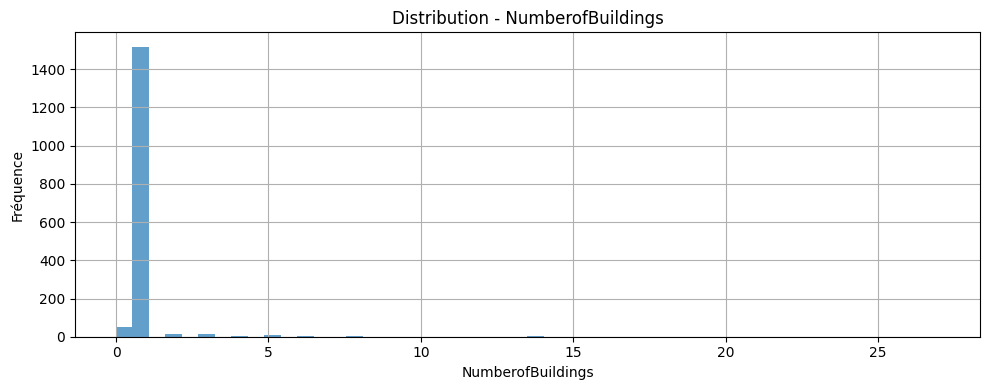

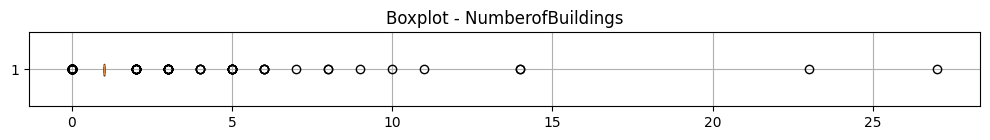

103 valeur(s) aberrante(s) détectée(s) dans 'NumberofBuildings'

Top 5 des valeurs min :
- 0
- 0
- 0
- 0
- 0

Top 5 des valeurs max :
- 11
- 14
- 14
- 23
- 27


In [19]:
outliers_NumberofBuildings = analyse_colonne_numerique(df_troisieme_nettoyage, 'NumberofBuildings')

In [20]:
# df_troisieme_nettoyage[df_troisieme_nettoyage['NumberofBuildings'] == 111]

### Analyse colonne NumberofFloors

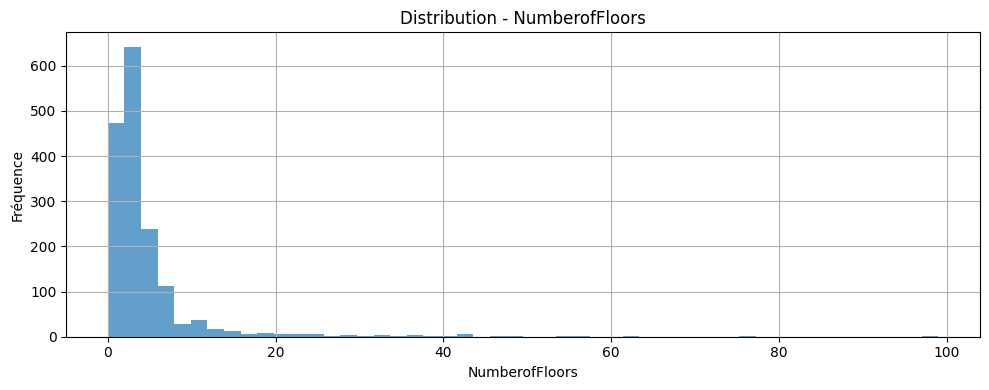

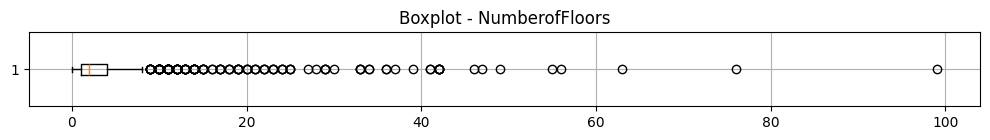

134 valeur(s) aberrante(s) détectée(s) dans 'NumberofFloors'

Top 5 des valeurs min :
- 0
- 0
- 0
- 0
- 0

Top 5 des valeurs max :
- 55
- 56
- 63
- 76
- 99


In [21]:
outliers_NumberofFloors = analyse_colonne_numerique(df_troisieme_nettoyage, 'NumberofFloors')

### Analyse colonne PropertyGFATotal

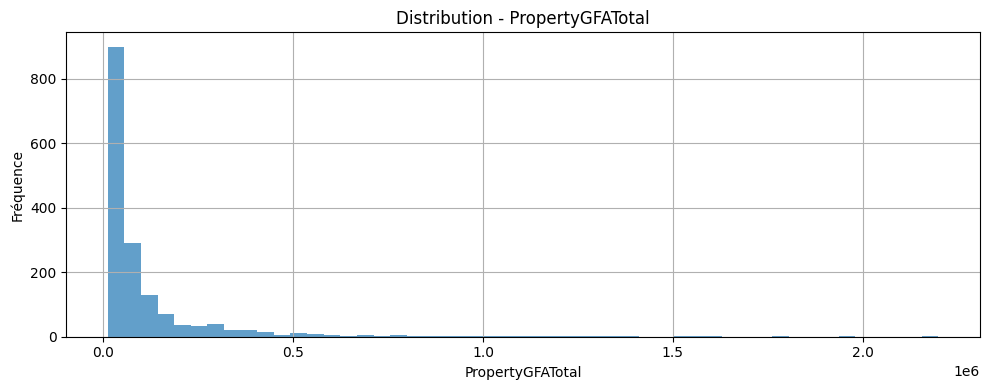

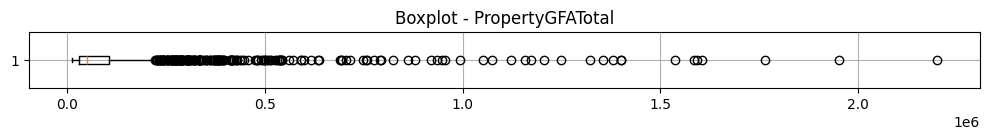

200 valeur(s) aberrante(s) détectée(s) dans 'PropertyGFATotal'

Top 5 des valeurs min :
- 11285
- 11685
- 11968
- 12294
- 12769

Top 5 des valeurs max :
- 1592914
- 1605578
- 1765970
- 1952220
- 2200000


In [22]:
# print(df_troisieme_nettoyage['PropertyGFATotal'].value_counts(dropna=False))
outliers_PropertyGFATotal = analyse_colonne_numerique(df_troisieme_nettoyage, 'PropertyGFATotal')

In [23]:
# outliers_PropertyGFATotal.sort_values(by='PropertyGFATotal', ascending=False).head()

### Analyse colonne PropertyGFAParking

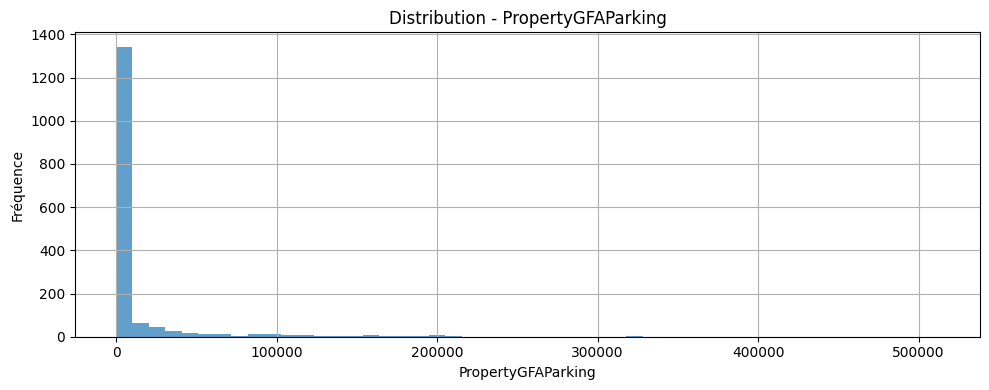

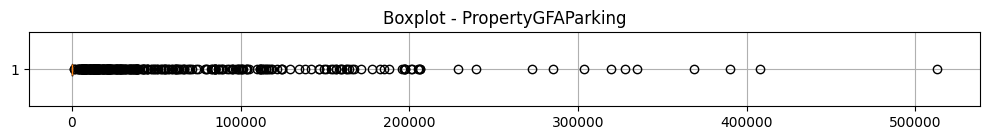

324 valeur(s) aberrante(s) détectée(s) dans 'PropertyGFAParking'

Top 5 des valeurs min :
- 0
- 0
- 0
- 0
- 0

Top 5 des valeurs max :
- 335109
- 368980
- 389860
- 407795
- 512608


In [24]:
outliers_PropertyGFAParking = analyse_colonne_numerique(df_troisieme_nettoyage, 'PropertyGFAParking')

In [25]:
# 512600ft en m ça fait 155600m donc c'est 155000m² ? 

### Analyse colonne PropertyGFABuilding(s)

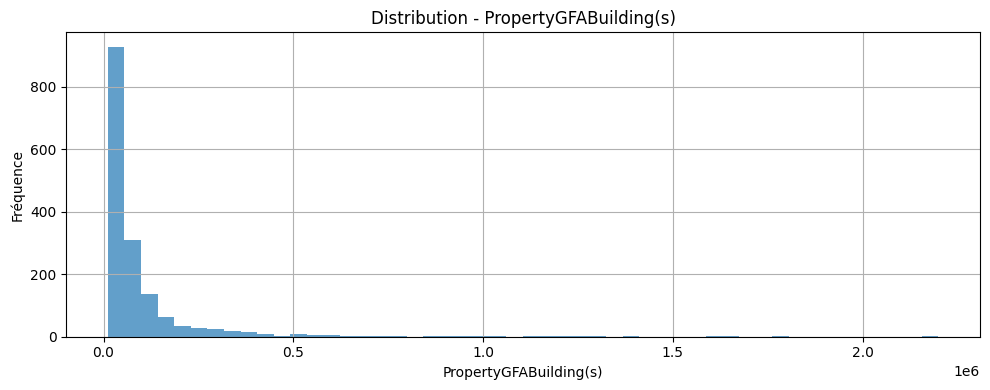

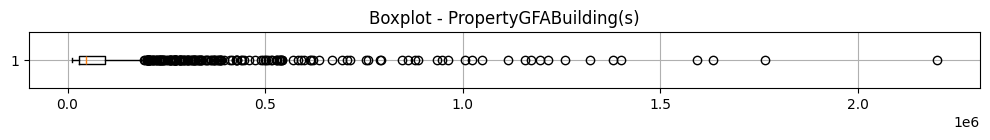

178 valeur(s) aberrante(s) détectée(s) dans 'PropertyGFABuilding(s)'

Top 5 des valeurs min :
- 10925
- 11285
- 11440
- 11685
- 11968

Top 5 des valeurs max :
- 1400000
- 1592914
- 1632820
- 1765970
- 2200000


In [26]:
outliers_PropertyGFABuilding = analyse_colonne_numerique(df_troisieme_nettoyage, 'PropertyGFABuilding(s)')

### Analyse colonne LargestPropertyUseTypeGFA

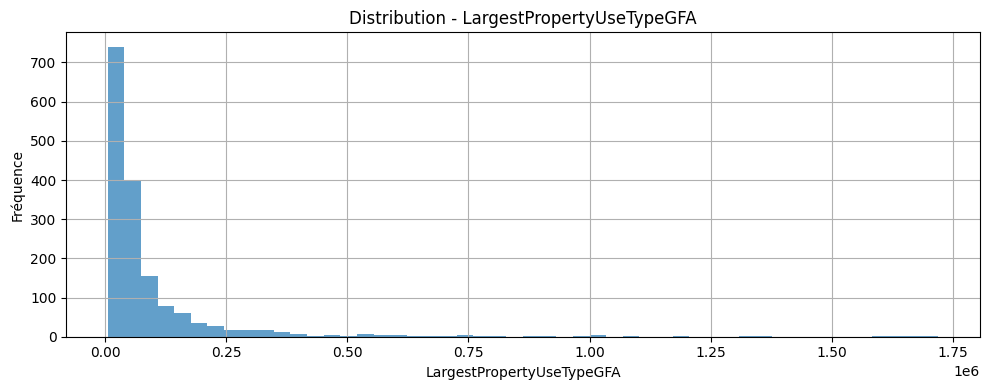

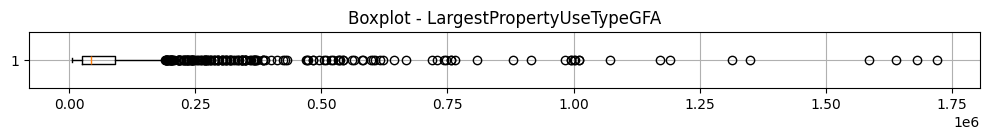

170 valeur(s) aberrante(s) détectée(s) dans 'LargestPropertyUseTypeGFA'

Top 5 des valeurs min :
- 5656
- 6455
- 6601
- 6900
- 7245

Top 5 des valeurs max :
- 1350182
- 1585960
- 1639334
- 1680937
- 1719643


In [27]:
outliers_LargestPropertyUseTypeGFA = analyse_colonne_numerique(df_troisieme_nettoyage, 'LargestPropertyUseTypeGFA')

### Analyse colonne ENERGYSTARScore

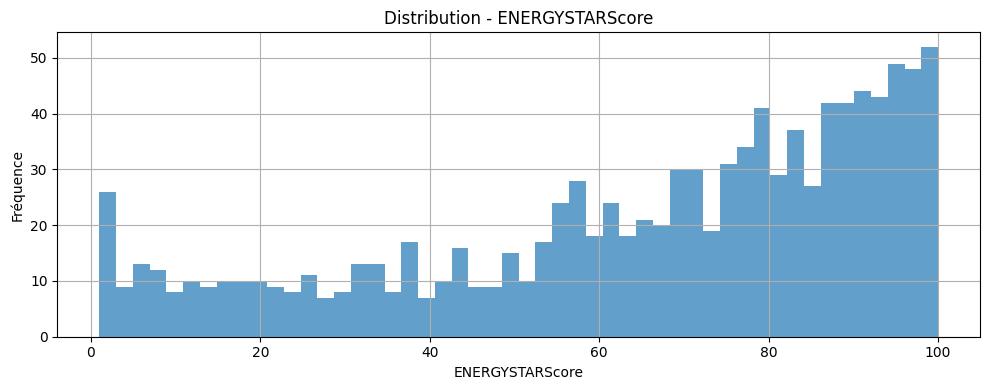

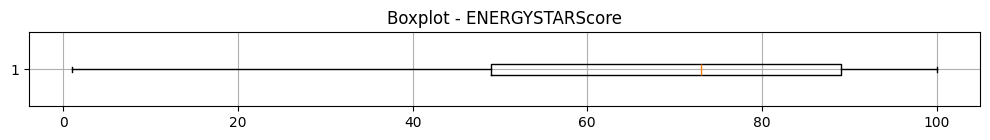

0 valeur(s) aberrante(s) détectée(s) dans 'ENERGYSTARScore'

Top 5 des valeurs min :
- 1.0
- 1.0
- 1.0
- 1.0
- 1.0

Top 5 des valeurs max :
- 100.0
- 100.0
- 100.0
- 100.0
- 100.0


In [28]:
outliers_ENERGYSTARScore = analyse_colonne_numerique(df_troisieme_nettoyage, 'ENERGYSTARScore')

### Analyse colonne SiteEUI(kBtu/sf)

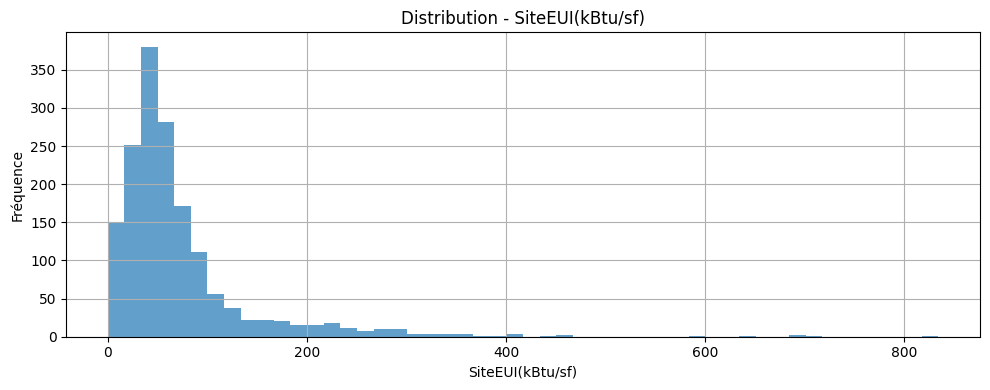

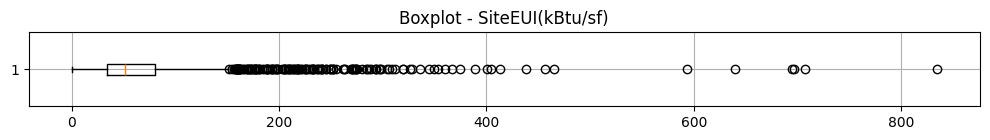

157 valeur(s) aberrante(s) détectée(s) dans 'SiteEUI(kBtu/sf)'

Top 5 des valeurs min :
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0

Top 5 des valeurs max :
- 639.7000122
- 694.7000122
- 696.7000122
- 707.2999878
- 834.4000244


In [29]:
outliers_SiteEUI = analyse_colonne_numerique(df_troisieme_nettoyage, 'SiteEUI(kBtu/sf)')

Site EUI signifie Site Energy Use Intensity = Intensité d’utilisation d’énergie du site.

SiteEUI =  Eˊnergie totale utiliseˊe sur site (en kBtu) / ​Surface brute totale (en pieds²)

kBtu = kilo British Thermal Units (1 kBtu ≈ 0,293 kWh)

sf = square feet (pieds carrés)

SiteEUI mesure combien d’énergie est utilisée par pied carré sur le site total, peu importe l’origine de l’énergie.

### Analyse colonne SiteEUIWN(kBtu/sf)

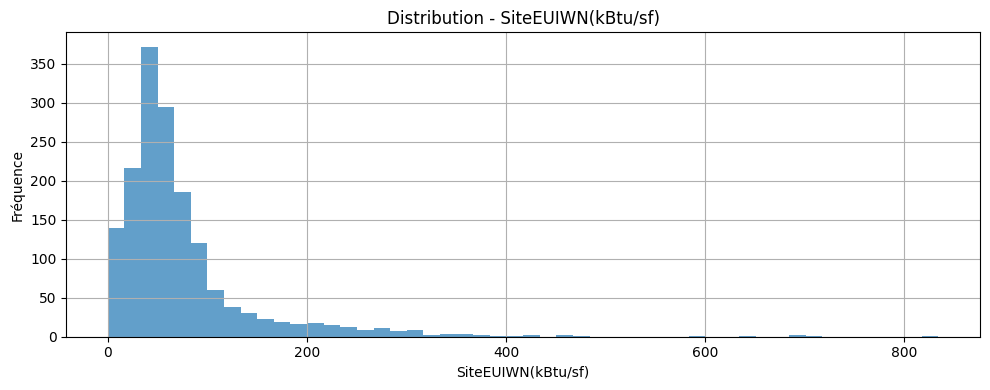

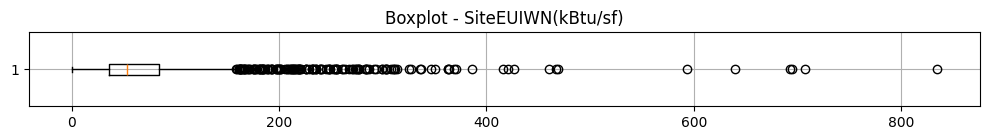

152 valeur(s) aberrante(s) détectée(s) dans 'SiteEUIWN(kBtu/sf)'

Top 5 des valeurs min :
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0

Top 5 des valeurs max :
- 639.7999878
- 693.0999756
- 694.7000122
- 707.2999878
- 834.4000244


In [30]:
outliers_SiteEUIWN = analyse_colonne_numerique(df_troisieme_nettoyage, 'SiteEUIWN(kBtu/sf)')

Site EUI Weather Normalized = Intensité énergétique du site corrigée en fonction du climat.

Parce que la météo influence la consommation :

Hiver rigoureux = plus de chauffage

Été chaud = plus de climatisation

Donc SiteEUIWN modélise la consommation d’énergie comme si la météo avait été "normale", pour comparer les bâtiments plus équitablement.

### Analyse colonne SourceEUI(kBtu/sf)

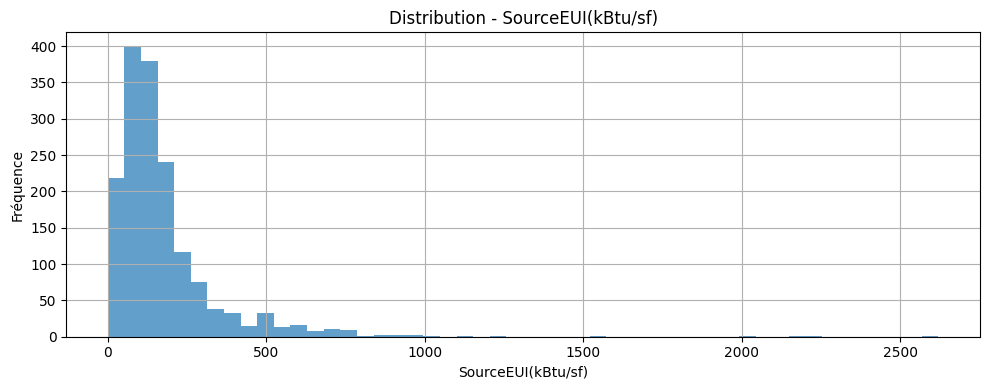

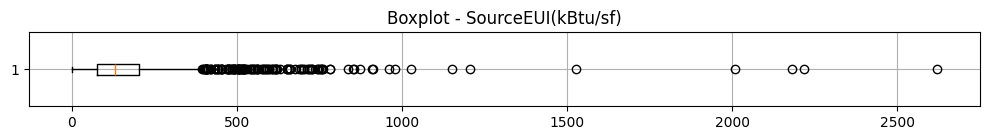

136 valeur(s) aberrante(s) détectée(s) dans 'SourceEUI(kBtu/sf)'

Top 5 des valeurs min :
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0

Top 5 des valeurs max :
- 1527.300049
- 2007.900024
- 2181.300049
- 2217.800049
- 2620.0


In [31]:
outliers_SourceEUI = analyse_colonne_numerique(df_troisieme_nettoyage, 'SourceEUI(kBtu/sf)')

Source Energy Use Intensity = Intensité d’utilisation de l’énergie à la source

SourceEUI (ce que tu ne vois pas) = Énergie nécessaire à la source pour fournir de l'énergie au site

Tu consommes 100 kWh d’électricité dans ton bâtiment.
Mais il faut ~300 kWh à la centrale pour produire et transporter cette électricité (pertes, rendement...).

- SiteEUI → 100 kWh
- SourceEUI → 300 kWh (car ça reflète ce que l'environnement a dû fournir)

SourceEUI est donc toujours supérieur ou égal à SiteEUI.

In [32]:
for i, row in df_troisieme_nettoyage.iterrows():
    site_eui = row['SiteEUI(kBtu/sf)']
    source_eui = row['SourceEUI(kBtu/sf)']

    if pd.notna(site_eui) and pd.notna(source_eui):
        if site_eui > source_eui:
            print(f"Ligne {i} : SiteEUI ({site_eui}) > SourceEUI ({source_eui})")

Ligne 437 : SiteEUI (58.0) > SourceEUI (28.0)
Ligne 498 : SiteEUI (208.8000031) > SourceEUI (0.0)
Ligne 1427 : SiteEUI (39.79999924) > SourceEUI (16.39999962)
Ligne 1436 : SiteEUI (89.19999695) > SourceEUI (0.0)


In [33]:
df_troisieme_nettoyage[df_troisieme_nettoyage['SourceEUI(kBtu/sf)'] == 28.0]

,OSEBuildingID,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
437,608,NonResidential,Large Office,98104,2,DOWNTOWN,1913,5,7,154159,0,154159,Office,Office,193154,NaN,NaN,NaN,NaN,NaN,100.0,58.0,58.799999,28.0,28.700001,11195917.0,11348758.0,0.0,471503.0,1608768.0,3430.500488,343050.0,Non-Compliant,29.43,0.19


In [34]:
df_troisieme_nettoyage[df_troisieme_nettoyage['OSEBuildingID'] == 700]

,OSEBuildingID,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
498,700,NonResidential,Supermarket / Grocery Store,98119,7,MAGNOLIA / QUEEN ANNE,2008,1,1,57176,0,57176,"Personal Services (Health/Beauty, Dry Cleaning...",Supermarket/Grocery Store,39500,Retail Store,15000.0,"Personal Services (Health/Beauty, Dry Cleaning...",5500.0,NaN,31.0,208.800003,214.100006,0.0,0.0,12525174.0,12843856.0,0.0,0.0,0.0,0.0,0.0,Compliant,0.0,0.0


In [35]:
# df_troisieme_nettoyage.iloc[[1436]]
df_troisieme_nettoyage[df_troisieme_nettoyage['OSEBuildingID'] == 26973]

,OSEBuildingID,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
1436,26973,NonResidential,Mixed Use Property,98104,2,DOWNTOWN,1909,1,3,49299,0,49299,"Multifamily Housing, Office, Restaurant",Office,24099,Multifamily Housing,23632.0,Restaurant,5320.0,NaN,NaN,89.199997,90.900002,0.0,0.0,4729846.5,4821852.0,0.0,387981.3125,1323792.0,0.0,0.0,Compliant,9.23,0.19


In [36]:
df_troisieme_nettoyage[df_troisieme_nettoyage['SourceEUI(kBtu/sf)'] == 16.39999962]

,OSEBuildingID,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
1427,26849,NonResidential,Retail Store,98104,2,DOWNTOWN,1917,1,2,24550,0,24550,"Office, Retail Store",Retail Store,13500,Office,11050.0,NaN,NaN,NaN,100.0,39.799999,42.0,16.4,17.700001,977230.3125,1.031448e+06,0.0,26436.40039,90201.0,1147.940186,114794.0,Compliant,6.73,0.27
1440,27007,NonResidential,Worship Facility,98105,4,NORTHEAST,1954,1,2,20039,0,20039,Worship Facility,Worship Facility,20039,NaN,NaN,NaN,NaN,NaN,100.0,5.200000,5.2,16.4,16.400000,104722.2969,1.047223e+05,0.0,30692.30078,104722.0,0.000000,0.0,Non-Compliant,0.73,0.04


In [37]:
df_troisieme_nettoyage[df_troisieme_nettoyage['OSEBuildingID'] == 26994]

,OSEBuildingID,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
1438,26994,NonResidential,Mixed Use Property,98122,3,EAST,1988,1,2,21036,0,21036,"Fitness Center/Health Club/Gym, Medical Office...",Parking,11021,Fitness Center/Health Club/Gym,8164.0,Office,7280.0,NaN,NaN,130.100006,134.600006,280.700012,285.399994,2735811.5,2830649.5,0.0,425240.4063,1450920.0,12848.91016,1284891.0,Compliant,78.36,3.73


In [38]:
# Remplacement des 0 par des NaN pour ne pas fausser les calculs si j'utilise les colonnes enquestion 

ids_cibles = [1436, 26973]

df_troisieme_nettoyage.loc[(df_troisieme_nettoyage['OSEBuildingID'].isin(ids_cibles)) & (df_troisieme_nettoyage['SourceEUI(kBtu/sf)'] == 0),
                            'SourceEUI(kBtu/sf)'] = np.nan
df_troisieme_nettoyage.loc[(df_troisieme_nettoyage['OSEBuildingID'].isin(ids_cibles)) & (df_troisieme_nettoyage['SourceEUIWN(kBtu/sf)'] == 0), 
                           'SourceEUIWN(kBtu/sf)'] = np.nan

### Analyse colonne SourceEUIWN(kBtu/sf)

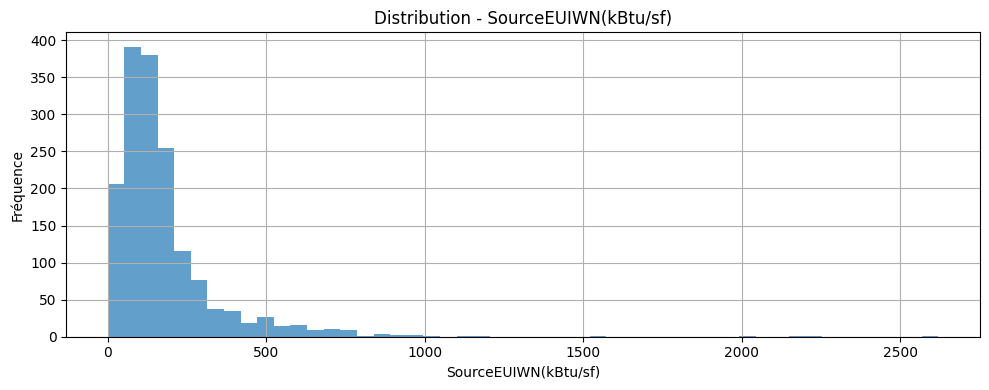

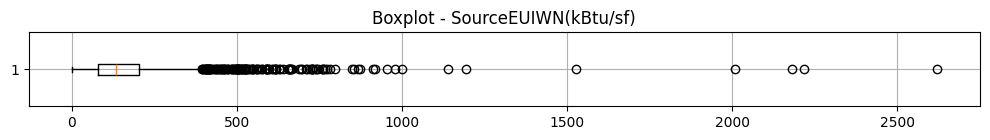

138 valeur(s) aberrante(s) détectée(s) dans 'SourceEUIWN(kBtu/sf)'

Top 5 des valeurs min :
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0

Top 5 des valeurs max :
- 1527.300049
- 2008.0
- 2181.300049
- 2217.800049
- 2620.0


In [39]:
outliers_SourceEUIWN = analyse_colonne_numerique(df_troisieme_nettoyage, 'SourceEUIWN(kBtu/sf)')

Même idée que pour SiteEUIWN : C’est une version corrigée selon les conditions climatiques normales.

Comme la météo varie, comparer deux bâtiments avec SourceEUIWN permet d’être plus juste

SourceEUIWN pour comparer objectivement des bâtiments

### Analyse colonne SiteEnergyUse(kBtu)

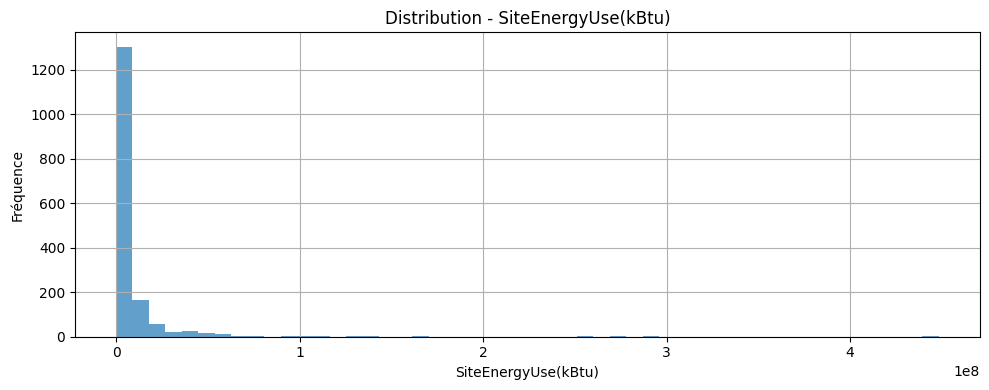

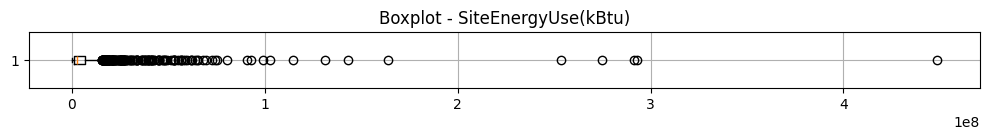

181 valeur(s) aberrante(s) détectée(s) dans 'SiteEnergyUse(kBtu)'

Top 5 des valeurs min :
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0

Top 5 des valeurs max :
- 253832464.0
- 274682208.0
- 291614432.0
- 293090784.0
- 448385312.0


In [40]:
outliers_SiteEnergyUse = analyse_colonne_numerique(df_troisieme_nettoyage, 'SiteEnergyUse(kBtu)')

C’est la quantité totale d’énergie utilisée sur le site (bâtiment, campus, etc.), exprimée en kBtu (kilo British Thermal Units)

- C’est l’énergie réellement consommée par le site (électricité, gaz, fuel, etc.)

- Elle est mesurée (ou estimée) à partir des compteurs réels ou des factures

In [41]:
df_troisieme_nettoyage[df_troisieme_nettoyage['SiteEnergyUse(kBtu)'] == 448385312.0]

,OSEBuildingID,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
34,43,Campus,Mixed Use Property,98108,2,GREATER DUWAMISH,1992,1,3,494835,0,494835,"Energy/Power Station, Laboratory, Manufacturin...",Office,757027,Laboratory,639931.0,Non-Refrigerated Warehouse,459748.0,NaN,8.0,221.699997,233.100006,388.200012,400.299988,448385312.0,471613856.0,0.0,44102076.0,150476283.0,2979090.0,297909000.0,Compliant,16870.98,34.09


### Analyse colonne SiteEnergyUseWN(kBtu)

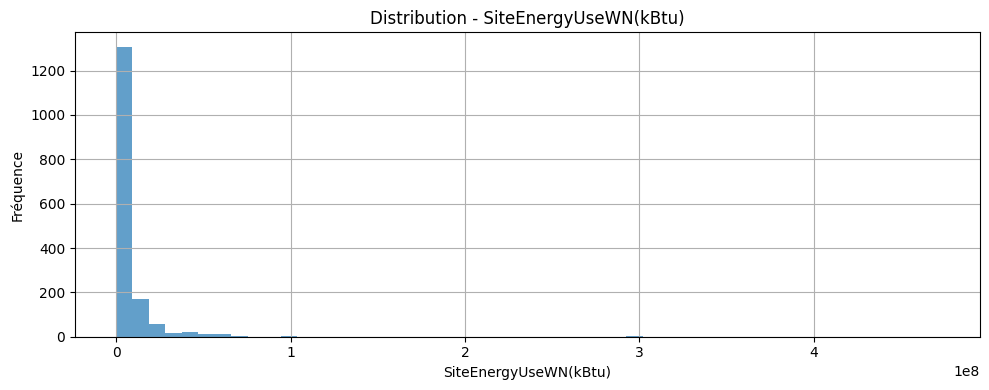

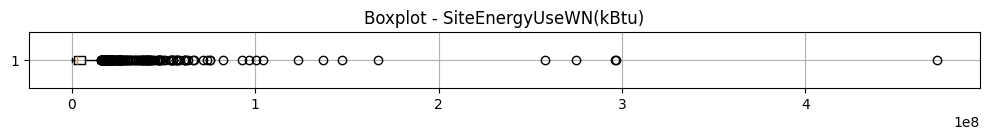

179 valeur(s) aberrante(s) détectée(s) dans 'SiteEnergyUseWN(kBtu)'

Top 5 des valeurs min :
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0

Top 5 des valeurs max :
- 257764208.0
- 274725984.0
- 295929888.0
- 296671744.0
- 471613856.0


In [42]:
outliers_SiteEnergyUseWN = analyse_colonne_numerique(df_troisieme_nettoyage, 'SiteEnergyUseWN(kBtu)')

Version normalisée selon la météo (Weather Normalized)

Parce que la consommation énergétique dépend énormément de la météo :

- hiver froid → plus de chauffage

- été chaud → plus de clim

Donc SiteEnergyUseWN modélise combien ton bâtiment aurait consommé dans des conditions météo typiques

### Analyse colonne SteamUse(kBtu)

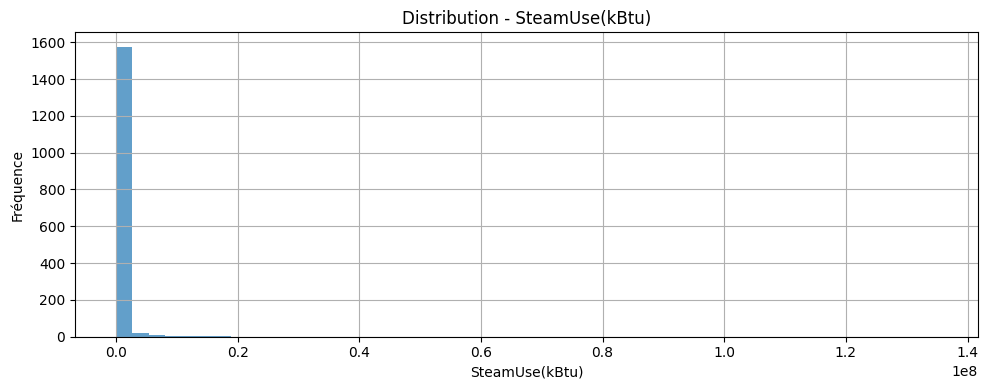

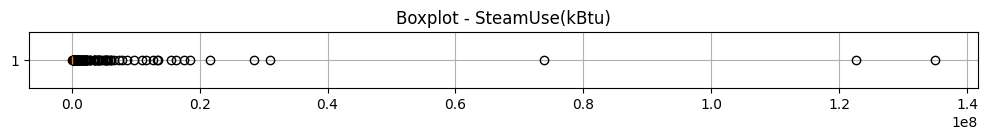

111 valeur(s) aberrante(s) détectée(s) dans 'SteamUse(kBtu)'

Top 5 des valeurs min :
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0

Top 5 des valeurs max :
- 28438884.0
- 31030194.0
- 73885472.0
- 122575032.0
- 134943456.0


In [43]:
outliers_SteamUse = analyse_colonne_numerique(df_troisieme_nettoyage, 'SteamUse(kBtu)')

Définition : Quantité de vapeur utilisée par le bâtiment, mesurée en kBtu

Source typique : réseaux de vapeur urbains ou chaudières collectives

Utilisation : chauffage, eau chaude sanitaire, parfois production industrielle

Inclus dans SiteEnergyUse normalement

Remarques analytiques :

- Très forte consommation dans les bâtiments anciens ou gros campus

- Peut être totalement absente dans des bâtiments individuels récents

In [44]:
df_troisieme_nettoyage[df_troisieme_nettoyage['SteamUse(kBtu)'] == 122575032.0]

,OSEBuildingID,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
165,276,NonResidential,Hospital,98104,3,EAST,2000,9,8,1158691,0,1158691,"Hospital (General Medical & Surgical), Parking",Hospital (General Medical & Surgical),1350182,Parking,387651.0,NaN,NaN,NaN,29.0,217.100006,219.699997,502.899994,502.799988,293090784.0,296671744.0,122575032.0,49438336.0,168683602.0,18321.29102,1832129.0,Compliant,10734.57,9.26


In [45]:
df_troisieme_nettoyage[df_troisieme_nettoyage['SteamUse(kBtu)'] == 134943456.0]

,OSEBuildingID,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
603,828,NonResidential,Hospital,98122,3,EAST,1994,7,14,1765970,0,1765970,"Hospital (General Medical & Surgical), Parking",Hospital (General Medical & Surgical),1639334,Parking,441551.0,NaN,NaN,NaN,54.0,177.899994,180.5,377.0,378.399994,291614432.0,295929888.0,134943456.0,40842564.0,139354828.0,173161.2031,17316120.0,Compliant,12307.16,6.97


### Analyse colonne Electricity(kWh)

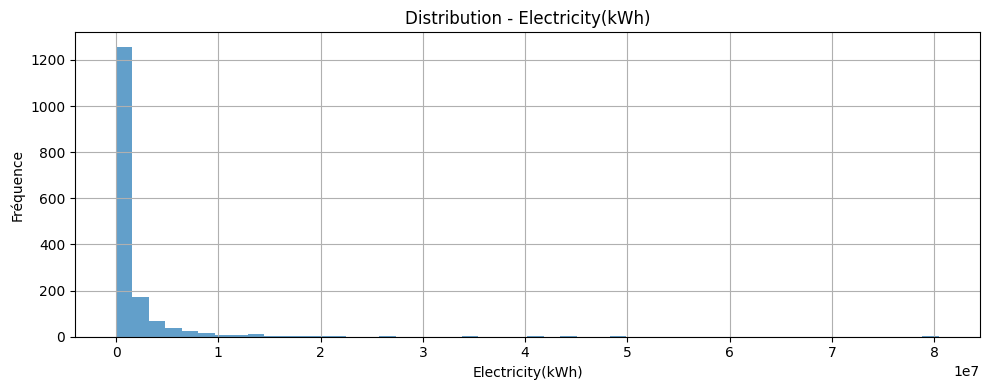

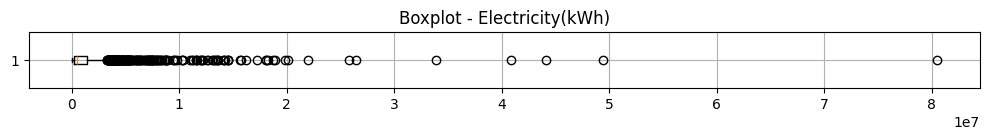

190 valeur(s) aberrante(s) détectée(s) dans 'Electricity(kWh)'

Top 5 des valeurs min :
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0

Top 5 des valeurs max :
- 33892500.0
- 40842564.0
- 44102076.0
- 49438336.0
- 80460872.0


In [46]:
outliers_Electricity = analyse_colonne_numerique(df_troisieme_nettoyage, 'Electricity(kWh)')

Définition : Électricité consommée, en kilowattheures

Unité brute d’électricité

1 kWh ≈ 3.412 kBtu (convertible)

In [47]:
df_troisieme_nettoyage[df_troisieme_nettoyage['Electricity(kWh)'] == 80460872.0]
# Data Center, Office

,OSEBuildingID,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
543,753,NonResidential,Other,98121,7,DOWNTOWN,1981,1,33,429405,0,429405,"Data Center, Office",Data Center,218997,Office,210409.0,NaN,NaN,NaN,98.0,639.700012,639.799988,2007.900024,2008.0,274682208.0,274725984.0,0.0,80460872.0,274532495.0,1496.720215,149672.0,Compliant,1921.82,4.48


### Analyse colonne Electricity(kBtu)

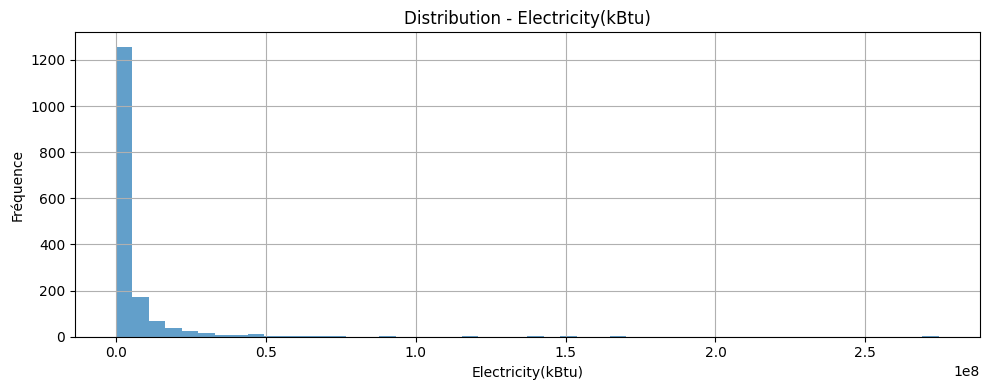

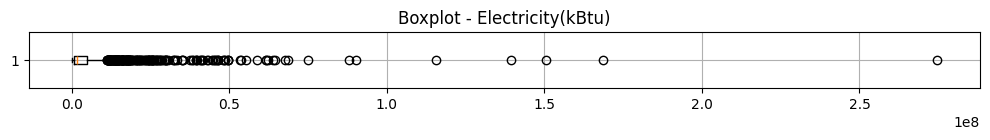

190 valeur(s) aberrante(s) détectée(s) dans 'Electricity(kBtu)'

Top 5 des valeurs min :
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0

Top 5 des valeurs max :
- 115641210.0
- 139354828.0
- 150476283.0
- 168683602.0
- 274532495.0


In [48]:
outliers_ElectricityB = analyse_colonne_numerique(df_troisieme_nettoyage, 'Electricity(kBtu)')

Version convertie de la colonne Electricity(kWh)

Electricity(kBtu)=Electricity(kWh)×3.412

C’est ce qui est utilisé dans SiteEnergyUse pour avoir toutes les énergies dans la même unité (kBtu)

In [49]:
# df_troisieme_nettoyage[df_troisieme_nettoyage['Electricity(kBtu)'] == -115417.0]

### Analyse colonne NaturalGas(therms)

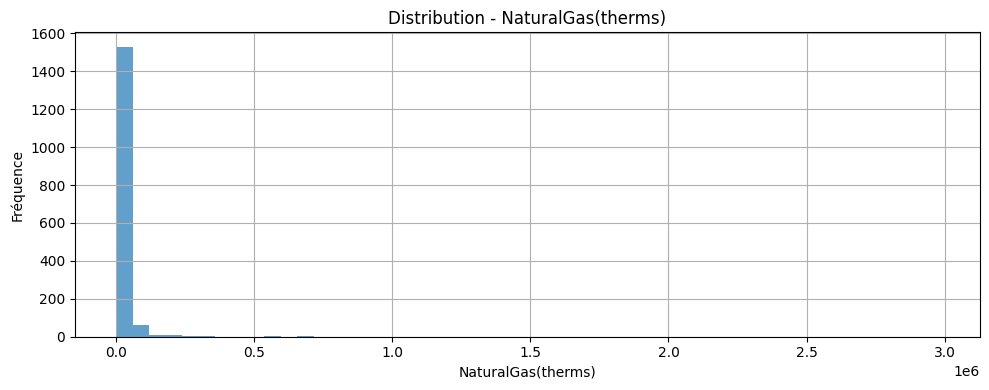

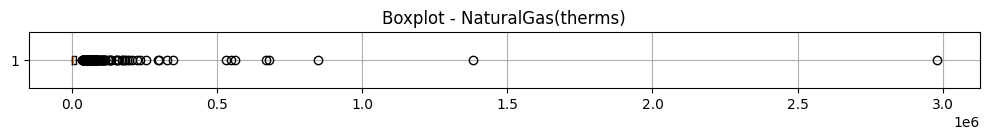

182 valeur(s) aberrante(s) détectée(s) dans 'NaturalGas(therms)'

Top 5 des valeurs min :
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0

Top 5 des valeurs max :
- 667464.25
- 679905.375
- 846680.9375
- 1381912.375
- 2979090.0


In [50]:
outliers_NaturalGas = analyse_colonne_numerique(df_troisieme_nettoyage, 'NaturalGas(therms)')

Gaz naturel consommé, en therms

1 therm = environ 100 kBtu



In [51]:
df_troisieme_nettoyage[df_troisieme_nettoyage['NaturalGas(therms)'] == 2979090.0]
# Campus, Energy/Power Station, Laboratory, Manufacturin

,OSEBuildingID,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
34,43,Campus,Mixed Use Property,98108,2,GREATER DUWAMISH,1992,1,3,494835,0,494835,"Energy/Power Station, Laboratory, Manufacturin...",Office,757027,Laboratory,639931.0,Non-Refrigerated Warehouse,459748.0,NaN,8.0,221.699997,233.100006,388.200012,400.299988,448385312.0,471613856.0,0.0,44102076.0,150476283.0,2979090.0,297909000.0,Compliant,16870.98,34.09


### Analyse colonne NaturalGas(kBtu)

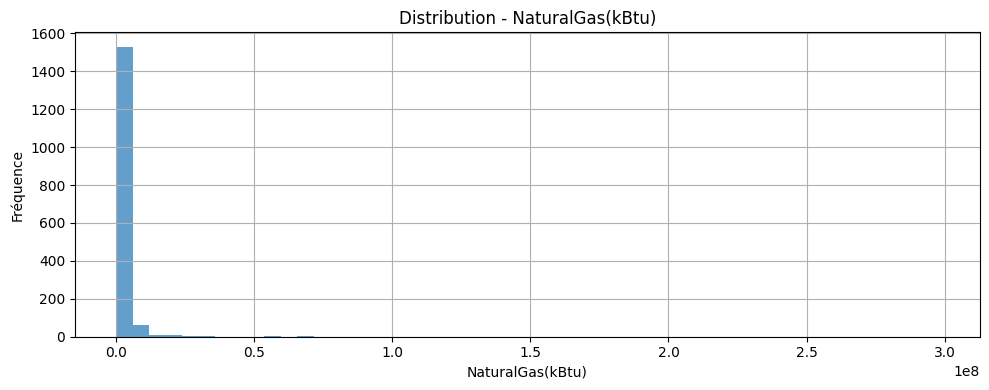

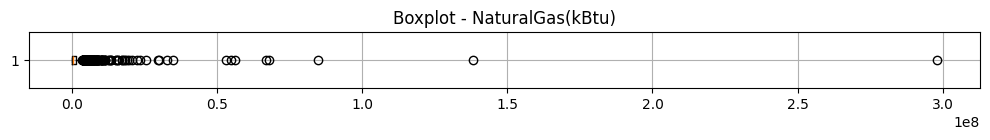

182 valeur(s) aberrante(s) détectée(s) dans 'NaturalGas(kBtu)'

Top 5 des valeurs min :
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0

Top 5 des valeurs max :
- 66746425.0
- 67990538.0
- 84668094.0
- 138191238.0
- 297909000.0


In [52]:
outliers_NaturalGas = analyse_colonne_numerique(df_troisieme_nettoyage, 'NaturalGas(kBtu)')

Énergie issue du gaz, convertie en kBtu


### Analyse colonne TotalGHGEmissions

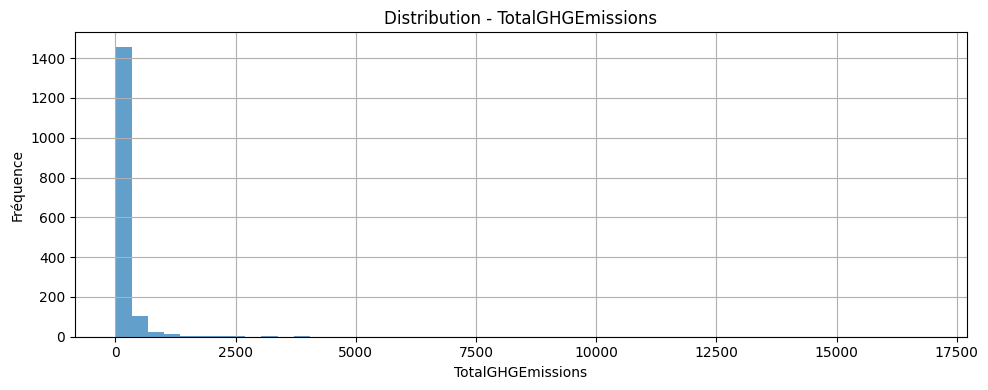

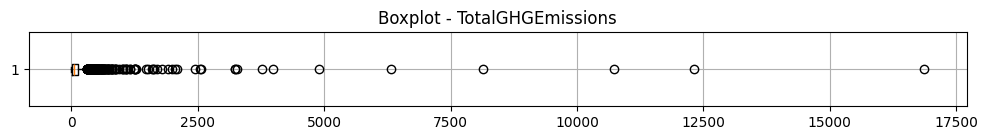

181 valeur(s) aberrante(s) détectée(s) dans 'TotalGHGEmissions'

Top 5 des valeurs min :
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0

Top 5 des valeurs max :
- 6330.91
- 8145.52
- 10734.57
- 12307.16
- 16870.98


In [53]:
outliers_TotalGHGEmissions = analyse_colonne_numerique(df_troisieme_nettoyage, 'TotalGHGEmissions')

Définition : Total des émissions de gaz à effet de serre du bâtiment, en général exprimé en kg ou tonnes équivalent CO₂

Inclut :

- émissions directes (ex : gaz brûlé sur site)

- émissions indirectes (ex : production d’électricité à distance)

Influencé par le mix énergétique :

- un kWh nucléaire ≠ un kWh charbon en émission

In [54]:
df_troisieme_nettoyage[df_troisieme_nettoyage['TotalGHGEmissions'] == -0.8]

,OSEBuildingID,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity


### Analyse colonne GHGEmissionsIntensity

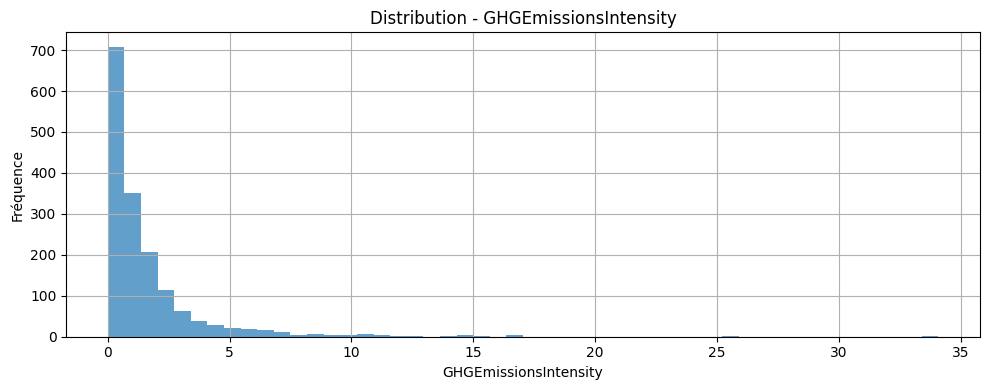

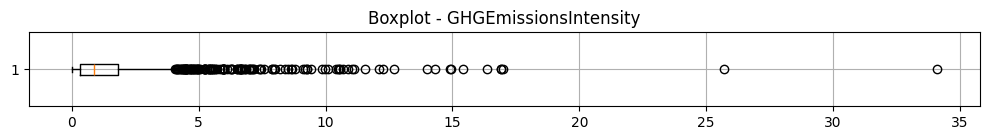

139 valeur(s) aberrante(s) détectée(s) dans 'GHGEmissionsIntensity'

Top 5 des valeurs min :
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0

Top 5 des valeurs max :
- 16.91
- 16.93
- 16.99
- 25.71
- 34.09


In [55]:
outliers_GHGEmissionsIntensity = analyse_colonne_numerique(df_troisieme_nettoyage, 'GHGEmissionsIntensity')

Définition : Intensité des émissions GES par unité de surface

En général :

GHG Intensity = TotalGHGEmissions / Surface (ft²)

Unité : souvent kgCO₂e / ft²

Permet de comparer les bâtiments de tailles différentes

- Comme un EUI pour les émissions.

### Analyse d'autres données

In [56]:
# # De 0 à 99, c'est ok
# df_troisieme_nettoyage['NumberofFloors'].value_counts(dropna=False)

In [57]:
# # De 1900 à 2015, c'est ok
# df_troisieme_nettoyage['YearBuilt'].value_counts(dropna=False).sort_index().index.tolist()

In [58]:
building_consumption['PropertyGFATotal'].value_counts(dropna=False)

PropertyGFATotal
36000     9
25920     8
28800     7
21600     7
24000     6
         ..
56228     1
88592     1
126593    1
67224     1
59653     1
Name: count, Length: 3195, dtype: int64

### NumberOfBuilding a 2 valeurs à NaN voir si je peux les remplacer ? 

In [59]:
# Finalement toutes les colonnes avec des données sur les dépenses energetiques sont vides pour les 2 valeurs à NaN
# je vais donc les retirer

# df_troisieme_nettoyage[df_troisieme_nettoyage['NumberofBuildings'].isnull()]
df_troisieme_nettoyage = df_troisieme_nettoyage.dropna(subset=['NumberofBuildings'])
print(df_troisieme_nettoyage.shape)
df_troisieme_nettoyage

(1620, 35)


,OSEBuildingID,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
0,1,NonResidential,Hotel,98101,7,DOWNTOWN,1927,1,12,88434,0,88434,Hotel,Hotel,88434,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7.226362e+06,7.456910e+06,2003882.00,1.156514e+06,3.946027e+06,12764.529300,1.276453e+06,Compliant,249.98,2.83
1,2,NonResidential,Hotel,98101,7,DOWNTOWN,1996,1,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8.387933e+06,8.664479e+06,0.00,9.504252e+05,3.242851e+06,51450.816410,5.145082e+06,Compliant,295.86,2.86
2,3,NonResidential,Hotel,98101,7,DOWNTOWN,1969,1,41,956110,196718,759392,Hotel,Hotel,756493,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,7.258702e+07,7.393711e+07,21566554.00,1.451544e+07,4.952666e+07,14938.000000,1.493800e+06,Compliant,2089.28,2.19
3,5,NonResidential,Hotel,98101,7,DOWNTOWN,1926,1,10,61320,0,61320,Hotel,Hotel,61320,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6.794584e+06,6.946800e+06,2214446.25,8.115253e+05,2.768924e+06,18112.130860,1.811213e+06,Compliant,286.43,4.67
4,8,NonResidential,Hotel,98121,7,DOWNTOWN,1980,1,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,1.417261e+07,1.465650e+07,0.00,1.573449e+06,5.368607e+06,88039.984380,8.803998e+06,Compliant,505.01,2.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1619,50222,Nonresidential COS,Office,<NA>,2,GREATER DUWAMISH,1990,1,1,12294,0,12294,Office,Office,12294,NaN,NaN,NaN,NaN,NaN,46.0,69.099998,76.699997,161.699997,176.100006,8.497457e+05,9.430032e+05,0.00,1.536550e+05,5.242709e+05,3254.750244,3.254750e+05,Error - Correct Default Data,20.94,1.70
1620,50223,Nonresidential COS,Other,<NA>,2,DOWNTOWN,2004,1,1,16000,0,16000,Other - Recreation,Other - Recreation,16000,NaN,NaN,NaN,NaN,NaN,NaN,59.400002,65.900002,114.199997,118.900002,9.502762e+05,1.053706e+06,0.00,1.162210e+05,3.965461e+05,5537.299805,5.537300e+05,Compliant,32.17,2.01
1621,50224,Nonresidential COS,Other,<NA>,7,MAGNOLIA / QUEEN ANNE,1974,1,1,13157,0,13157,"Fitness Center/Health Club/Gym, Other - Recrea...",Other - Recreation,7583,Fitness Center/Health Club/Gym,5574.0,Swimming Pool,0.0,NaN,NaN,438.200012,460.100006,744.799988,767.799988,5.765898e+06,6.053764e+06,0.00,5.252517e+05,1.792159e+06,39737.390630,3.973739e+06,Compliant,223.54,16.99
1622,50225,Nonresidential COS,Mixed Use Property,<NA>,1,GREATER DUWAMISH,1989,1,1,14101,0,14101,"Fitness Center/Health Club/Gym, Food Service, ...",Other - Recreation,6601,Fitness Center/Health Club/Gym,6501.0,Pre-school/Daycare,484.0,NaN,NaN,51.000000,55.500000,105.300003,110.800003,7.194712e+05,7.828413e+05,0.00,1.022480e+05,3.488702e+05,3706.010010,3.706010e+05,Compliant,22.11,1.57


### Nouveau control des données

In [60]:
df_troisieme_nettoyage

,OSEBuildingID,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
0,1,NonResidential,Hotel,98101,7,DOWNTOWN,1927,1,12,88434,0,88434,Hotel,Hotel,88434,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7.226362e+06,7.456910e+06,2003882.00,1.156514e+06,3.946027e+06,12764.529300,1.276453e+06,Compliant,249.98,2.83
1,2,NonResidential,Hotel,98101,7,DOWNTOWN,1996,1,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8.387933e+06,8.664479e+06,0.00,9.504252e+05,3.242851e+06,51450.816410,5.145082e+06,Compliant,295.86,2.86
2,3,NonResidential,Hotel,98101,7,DOWNTOWN,1969,1,41,956110,196718,759392,Hotel,Hotel,756493,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,7.258702e+07,7.393711e+07,21566554.00,1.451544e+07,4.952666e+07,14938.000000,1.493800e+06,Compliant,2089.28,2.19
3,5,NonResidential,Hotel,98101,7,DOWNTOWN,1926,1,10,61320,0,61320,Hotel,Hotel,61320,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6.794584e+06,6.946800e+06,2214446.25,8.115253e+05,2.768924e+06,18112.130860,1.811213e+06,Compliant,286.43,4.67
4,8,NonResidential,Hotel,98121,7,DOWNTOWN,1980,1,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,1.417261e+07,1.465650e+07,0.00,1.573449e+06,5.368607e+06,88039.984380,8.803998e+06,Compliant,505.01,2.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1619,50222,Nonresidential COS,Office,<NA>,2,GREATER DUWAMISH,1990,1,1,12294,0,12294,Office,Office,12294,NaN,NaN,NaN,NaN,NaN,46.0,69.099998,76.699997,161.699997,176.100006,8.497457e+05,9.430032e+05,0.00,1.536550e+05,5.242709e+05,3254.750244,3.254750e+05,Error - Correct Default Data,20.94,1.70
1620,50223,Nonresidential COS,Other,<NA>,2,DOWNTOWN,2004,1,1,16000,0,16000,Other - Recreation,Other - Recreation,16000,NaN,NaN,NaN,NaN,NaN,NaN,59.400002,65.900002,114.199997,118.900002,9.502762e+05,1.053706e+06,0.00,1.162210e+05,3.965461e+05,5537.299805,5.537300e+05,Compliant,32.17,2.01
1621,50224,Nonresidential COS,Other,<NA>,7,MAGNOLIA / QUEEN ANNE,1974,1,1,13157,0,13157,"Fitness Center/Health Club/Gym, Other - Recrea...",Other - Recreation,7583,Fitness Center/Health Club/Gym,5574.0,Swimming Pool,0.0,NaN,NaN,438.200012,460.100006,744.799988,767.799988,5.765898e+06,6.053764e+06,0.00,5.252517e+05,1.792159e+06,39737.390630,3.973739e+06,Compliant,223.54,16.99
1622,50225,Nonresidential COS,Mixed Use Property,<NA>,1,GREATER DUWAMISH,1989,1,1,14101,0,14101,"Fitness Center/Health Club/Gym, Food Service, ...",Other - Recreation,6601,Fitness Center/Health Club/Gym,6501.0,Pre-school/Daycare,484.0,NaN,NaN,51.000000,55.500000,105.300003,110.800003,7.194712e+05,7.828413e+05,0.00,1.022480e+05,3.488702e+05,3706.010010,3.706010e+05,Compliant,22.11,1.57


In [61]:
df_troisieme_nettoyage.describe()

,OSEBuildingID,ZipCode,CouncilDistrictCode,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
count,1620.000000,1604.0,1620.000000,1620.000000,1620.0,1620.000000,1.620000e+03,1620.000000,1.620000e+03,1616.0,836.000000,346.000000,1055.000000,1619.000000,1619.000000,1619.000000,1619.000000,1.620000e+03,1.619000e+03,1.620000e+03,1.620000e+03,1.620000e+03,1.620000e+03,1.620000e+03,1620.000000,1620.000000
mean,16046.958025,98116.659601,4.354938,1961.794444,1.106173,4.125926,1.138812e+05,13070.101235,1.008111e+05,93255.992574,37296.386719,15122.590748,65.681517,71.974491,74.409697,176.244904,178.566646,7.942639e+06,8.089147e+06,4.715826e+05,1.613802e+06,5.506291e+06,1.932270e+04,1.932270e+06,177.409895,1.585753
std,13708.668562,18.023242,2.205461,32.681484,1.175133,6.633264,1.958551e+05,42686.210442,1.742020e+05,160281.185736,70508.759868,37130.929244,28.302697,74.497765,75.419389,187.836079,187.733443,2.180814e+07,2.229637e+07,5.181317e+06,3.955300e+06,1.349548e+07,9.454710e+04,9.454710e+06,710.364316,2.328898
min,1.000000,98006.0,1.000000,1900.000000,0.0,0.000000,1.128500e+04,0.000000,1.092500e+04,5656.0,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,575.750000,98105.0,2.000000,1930.000000,1.0,1.000000,2.941275e+04,0.000000,2.838975e+04,25500.0,5406.000000,2667.000000,49.000000,33.700001,35.400002,76.350002,79.149998,1.216921e+06,1.282894e+06,0.000000e+00,2.110412e+05,7.200730e+05,0.000000e+00,0.000000e+00,19.760000,0.340000
50%,21120.500000,98109.0,4.000000,1965.000000,1.0,2.000000,4.915450e+04,0.000000,4.722600e+04,43484.0,12155.000000,6000.000000,73.000000,51.400002,53.599998,130.699997,133.800003,2.500610e+06,2.654316e+06,0.000000e+00,4.672902e+05,1.594394e+06,4.783005e+03,4.783005e+05,49.105000,0.860000
75%,24560.750000,98124.25,7.000000,1989.000000,1.0,4.000000,1.048548e+05,0.000000,9.455325e+04,91560.25,32371.000000,13240.750000,89.000000,80.700001,84.450001,202.699997,204.500000,6.858700e+06,7.067208e+06,0.000000e+00,1.424109e+06,4.859058e+06,1.464761e+04,1.464761e+06,134.922500,1.820000
max,50226.000000,98199.0,7.000000,2015.000000,27.0,99.000000,2.200000e+06,512608.000000,2.200000e+06,1719643.0,686750.000000,459748.000000,100.000000,834.400024,834.400024,2620.000000,2620.000000,4.483853e+08,4.716139e+08,1.349435e+08,8.046087e+07,2.745325e+08,2.979090e+06,2.979090e+08,16870.980000,34.090000


In [62]:
dict(df_troisieme_nettoyage.isnull().sum())

{'OSEBuildingID': np.int64(0),
 'BuildingType': np.int64(0),
 'PrimaryPropertyType': np.int64(0),
 'ZipCode': np.int64(16),
 'CouncilDistrictCode': np.int64(0),
 'Neighborhood': np.int64(0),
 'YearBuilt': np.int64(0),
 'NumberofBuildings': np.int64(0),
 'NumberofFloors': np.int64(0),
 'PropertyGFATotal': np.int64(0),
 'PropertyGFAParking': np.int64(0),
 'PropertyGFABuilding(s)': np.int64(0),
 'ListOfAllPropertyUseTypes': np.int64(0),
 'LargestPropertyUseType': np.int64(4),
 'LargestPropertyUseTypeGFA': np.int64(4),
 'SecondLargestPropertyUseType': np.int64(784),
 'SecondLargestPropertyUseTypeGFA': np.int64(784),
 'ThirdLargestPropertyUseType': np.int64(1274),
 'ThirdLargestPropertyUseTypeGFA': np.int64(1274),
 'YearsENERGYSTARCertified': np.int64(1522),
 'ENERGYSTARScore': np.int64(565),
 'SiteEUI(kBtu/sf)': np.int64(1),
 'SiteEUIWN(kBtu/sf)': np.int64(1),
 'SourceEUI(kBtu/sf)': np.int64(1),
 'SourceEUIWN(kBtu/sf)': np.int64(1),
 'SiteEnergyUse(kBtu)': np.int64(0),
 'SiteEnergyUseWN(kB

### Corrélation des données

In [63]:
df_troisieme_nettoyage.select_dtypes(include='number').corr()

,OSEBuildingID,ZipCode,CouncilDistrictCode,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
OSEBuildingID,1.000000,0.115094,-0.166651,-0.015639,-0.020276,-0.255790,-0.306134,-0.222528,-0.289658,-0.289233,-0.221979,-0.156436,-0.045308,0.000302,0.005293,-0.038417,-0.036799,-0.182213,-0.182789,-0.035356,-0.229994,-0.229994,-0.073756,-0.073756,-0.102503,0.091107
ZipCode,0.115094,1.000000,-0.194677,0.088365,-0.000599,-0.146006,-0.077856,-0.094800,-0.064281,-0.056569,-0.068683,-0.015652,0.005579,-0.071258,-0.078959,-0.062717,-0.071187,-0.057946,-0.062396,-0.047332,-0.057871,-0.057871,-0.028268,-0.028268,-0.054296,-0.074038
CouncilDistrictCode,-0.166651,-0.194677,1.000000,-0.048913,-0.035045,0.280751,0.172381,0.192599,0.146614,0.126735,0.175046,0.021332,0.105433,0.079749,0.071189,0.105241,0.100614,0.073868,0.069967,0.010057,0.121730,0.121730,-0.007265,-0.007265,0.016649,-0.002864
YearBuilt,-0.015639,0.088365,-0.048913,1.000000,0.031930,0.093186,0.210848,0.280435,0.168338,0.185231,0.256633,0.149715,-0.035207,0.127258,0.119597,0.160021,0.155656,0.135993,0.132687,0.016211,0.172990,0.172990,0.058292,0.058292,0.073243,-0.006284
NumberofBuildings,-0.020276,-0.000599,-0.035045,0.031930,1.000000,-0.022556,0.148661,-0.012154,0.170118,0.201396,0.149229,-0.000119,-0.035384,0.053152,0.054492,0.041198,0.042005,0.243944,0.245349,0.173440,0.206890,0.206890,0.170549,0.170549,0.245604,0.077487
NumberofFloors,-0.255790,-0.146006,0.280751,0.093186,-0.022556,1.000000,0.641904,0.507524,0.597329,0.604428,0.494369,0.252455,0.123925,0.028153,0.016858,0.067331,0.060624,0.324063,0.317256,0.106714,0.459287,0.459287,0.033103,0.033103,0.144308,-0.047899
PropertyGFATotal,-0.306134,-0.077856,0.172381,0.210848,0.148661,0.641904,1.000000,0.588196,0.980168,0.953306,0.802653,0.519056,0.130025,0.049435,0.034618,0.071059,0.064376,0.585329,0.581235,0.279285,0.669197,0.669197,0.240815,0.240815,0.416094,-0.006986
PropertyGFAParking,-0.222528,-0.094800,0.192599,0.280435,-0.012154,0.507524,0.588196,1.000000,0.416270,0.492023,0.458058,0.181431,0.095382,0.057724,0.050193,0.102537,0.097369,0.214363,0.210857,0.004429,0.324558,0.324558,0.029725,0.029725,0.066491,-0.091742
PropertyGFABuilding(s),-0.289658,-0.064281,0.146614,0.168338,0.170118,0.597329,0.980168,0.416270,1.000000,0.951220,0.789856,0.546947,0.124854,0.041408,0.026634,0.054766,0.048519,0.605558,0.601880,0.312915,0.672848,0.672848,0.263464,0.263464,0.451521,0.014626
LargestPropertyUseTypeGFA,-0.289233,-0.056569,0.126735,0.185231,0.201396,0.604428,0.953306,0.492023,0.951220,1.000000,0.763222,0.464767,0.119578,0.040644,0.027106,0.050147,0.043505,0.654080,0.651041,0.379231,0.695702,0.695702,0.306332,0.306332,0.522191,0.059207


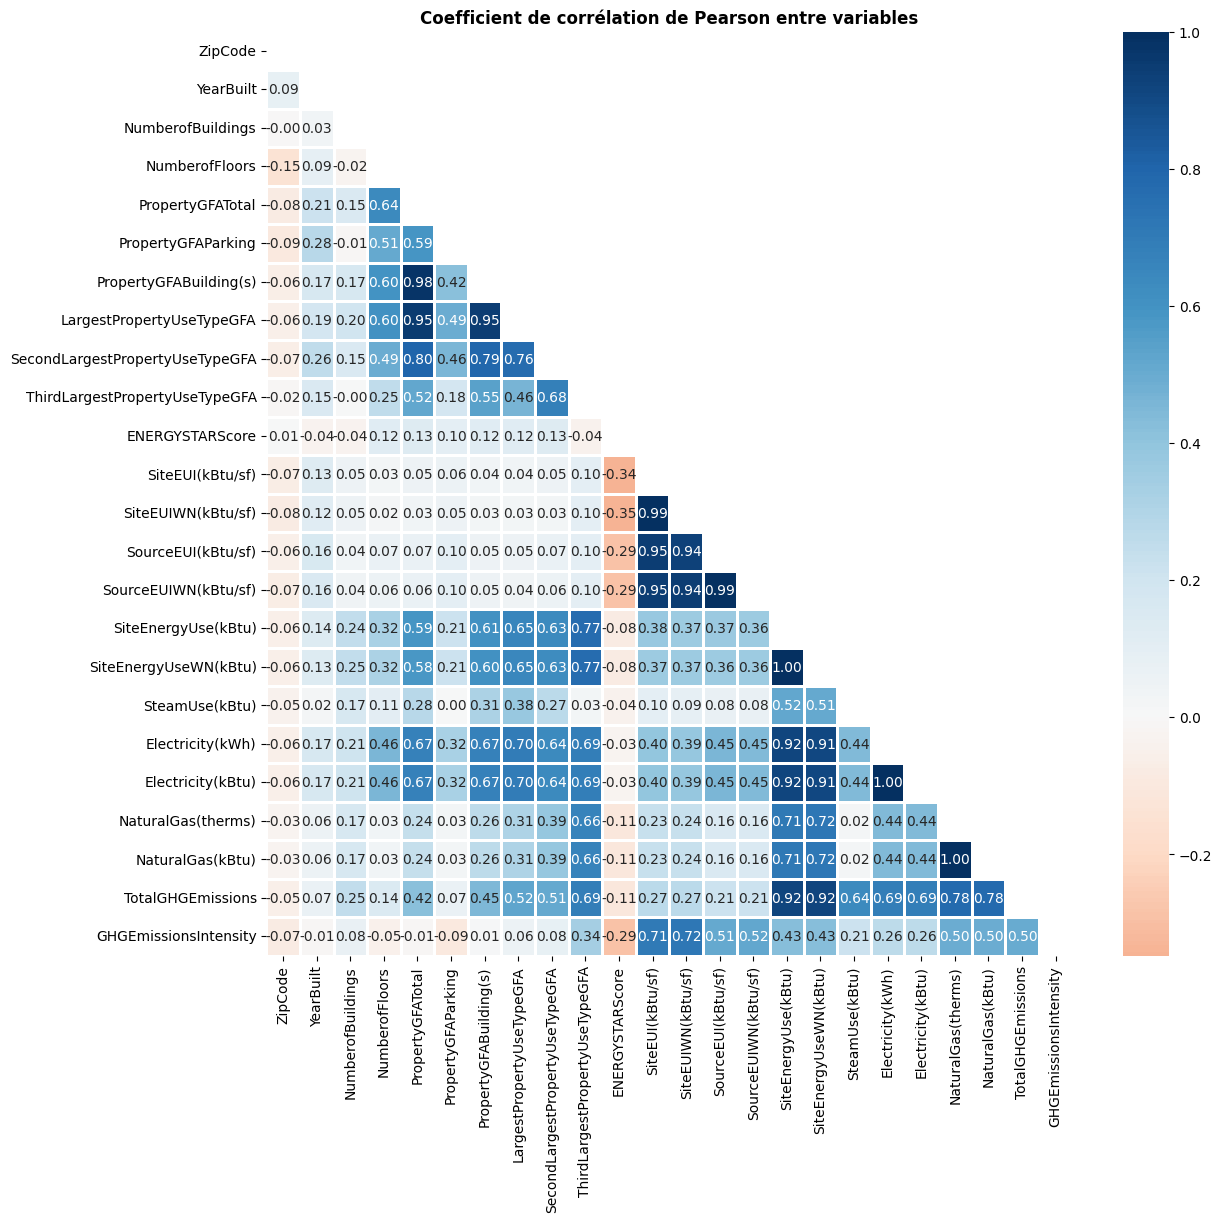

In [64]:
cols_to_exclude = ['OSEBuildingID', 'CouncilDistrictCode'] 

corr = (df_troisieme_nettoyage.select_dtypes(include='number').drop(columns=cols_to_exclude).corr())

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(13, 12))
sns.heatmap(corr, mask=mask, center=0, cmap='RdBu', linewidths=1, annot=True, fmt=".2f")
plt.title("Coefficient de corrélation de Pearson entre variables", fontweight="bold")
plt.show()

# Modélisation 

### Import des modules 

In [73]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

from sklearn.preprocessing import MultiLabelBinarizer
import re

In [67]:
df_clean = df_troisieme_nettoyage.copy()

### Choix des Features X et target y

In [69]:
df_clean

,OSEBuildingID,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
0,1,NonResidential,Hotel,98101,7,DOWNTOWN,1927,1,12,88434,0,88434,Hotel,Hotel,88434,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7.226362e+06,7.456910e+06,2003882.00,1.156514e+06,3.946027e+06,12764.529300,1.276453e+06,Compliant,249.98,2.83
1,2,NonResidential,Hotel,98101,7,DOWNTOWN,1996,1,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8.387933e+06,8.664479e+06,0.00,9.504252e+05,3.242851e+06,51450.816410,5.145082e+06,Compliant,295.86,2.86
2,3,NonResidential,Hotel,98101,7,DOWNTOWN,1969,1,41,956110,196718,759392,Hotel,Hotel,756493,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,7.258702e+07,7.393711e+07,21566554.00,1.451544e+07,4.952666e+07,14938.000000,1.493800e+06,Compliant,2089.28,2.19
3,5,NonResidential,Hotel,98101,7,DOWNTOWN,1926,1,10,61320,0,61320,Hotel,Hotel,61320,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6.794584e+06,6.946800e+06,2214446.25,8.115253e+05,2.768924e+06,18112.130860,1.811213e+06,Compliant,286.43,4.67
4,8,NonResidential,Hotel,98121,7,DOWNTOWN,1980,1,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,1.417261e+07,1.465650e+07,0.00,1.573449e+06,5.368607e+06,88039.984380,8.803998e+06,Compliant,505.01,2.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1619,50222,Nonresidential COS,Office,<NA>,2,GREATER DUWAMISH,1990,1,1,12294,0,12294,Office,Office,12294,NaN,NaN,NaN,NaN,NaN,46.0,69.099998,76.699997,161.699997,176.100006,8.497457e+05,9.430032e+05,0.00,1.536550e+05,5.242709e+05,3254.750244,3.254750e+05,Error - Correct Default Data,20.94,1.70
1620,50223,Nonresidential COS,Other,<NA>,2,DOWNTOWN,2004,1,1,16000,0,16000,Other - Recreation,Other - Recreation,16000,NaN,NaN,NaN,NaN,NaN,NaN,59.400002,65.900002,114.199997,118.900002,9.502762e+05,1.053706e+06,0.00,1.162210e+05,3.965461e+05,5537.299805,5.537300e+05,Compliant,32.17,2.01
1621,50224,Nonresidential COS,Other,<NA>,7,MAGNOLIA / QUEEN ANNE,1974,1,1,13157,0,13157,"Fitness Center/Health Club/Gym, Other - Recrea...",Other - Recreation,7583,Fitness Center/Health Club/Gym,5574.0,Swimming Pool,0.0,NaN,NaN,438.200012,460.100006,744.799988,767.799988,5.765898e+06,6.053764e+06,0.00,5.252517e+05,1.792159e+06,39737.390630,3.973739e+06,Compliant,223.54,16.99
1622,50225,Nonresidential COS,Mixed Use Property,<NA>,1,GREATER DUWAMISH,1989,1,1,14101,0,14101,"Fitness Center/Health Club/Gym, Food Service, ...",Other - Recreation,6601,Fitness Center/Health Club/Gym,6501.0,Pre-school/Daycare,484.0,NaN,NaN,51.000000,55.500000,105.300003,110.800003,7.194712e+05,7.828413e+05,0.00,1.022480e+05,3.488702e+05,3706.010010,3.706010e+05,Compliant,22.11,1.57


In [72]:
df_clean['ListOfAllPropertyUseTypes'].value_counts()

ListOfAllPropertyUseTypes
Office                                                                                                                         137
K-12 School                                                                                                                    135
Office, Parking                                                                                                                120
Non-Refrigerated Warehouse                                                                                                     101
Non-Refrigerated Warehouse, Office                                                                                              61
                                                                                                                              ... 
Office, Other, Other - Restaurant/Bar, Strip Mall                                                                                1
Multifamily Housing, Parking, Personal Services (Health/B

In [68]:
df_clean.columns

Index(['OSEBuildingID', 'BuildingType', 'PrimaryPropertyType', 'ZipCode',
       'CouncilDistrictCode', 'Neighborhood', 'YearBuilt', 'NumberofBuildings',
       'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking',
       'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes',
       'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
       'YearsENERGYSTARCertified', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)',
       'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
       'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)',
       'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)',
       'NaturalGas(kBtu)', 'ComplianceStatus', 'TotalGHGEmissions',
       'GHGEmissionsIntensity'],
      dtype='object')

In [ ]:
# def lower_and_uniformisation(s: str) -> str:
#     s = s.lower().strip()
#     s = re.sub(r"[^\w]+", "_", s)
#     s = re.sub(r"_{2,}", "_", s).strip("_")
#     return s or "unknown"

# def split_use_list(series: pd.Series):
#     def split_one(x):
#         if pd.isna(x):
#             return []
#         items = [i.strip() for i in str(x).split(",")]
#         return [i for i in items if i]
#     return series.apply(split_one)

# # Transforme la colonne texte en listes
# use_lists = split_use_list(df_clean["ListOfAllPropertyUseTypes"])

# # Binarise (multi-hot)
# mlb = MultiLabelBinarizer()
# multi_hot = pd.DataFrame(
#     mlb.fit_transform(use_lists),
#     columns=[f"has_{lower_and_uniformisation(c)}" for c in mlb.classes_],
#     index=df_clean.index)

# # # Filtrer usages rares
# # min_count = 10   # ajuste selon la taille de ton dataset
# # col_counts = multi_hot.sum(0)
# # keep_cols = col_counts[col_counts >= min_count].index.tolist()
# # multi_hot = multi_hot[keep_cols] if len(keep_cols) else multi_hot

# # Intégrer dans X
# df_for_X = pd.concat([df_clean.drop(columns=["ListOfAllPropertyUseTypes"]), multi_hot], axis=1)
# df_for_X

In [76]:
X = df_clean[['YearBuilt', 'NumberofBuildings', 'PropertyGFATotal', 'LargestPropertyUseType']]

In [83]:
X.isna().value_counts()

YearBuilt  NumberofBuildings  PropertyGFATotal  LargestPropertyUseType
False      False              False             False                     1616
                                                True                         4
Name: count, dtype: int64

In [77]:
y = df_clean[['SiteEnergyUse(kBtu)']]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [79]:
linreg = LinearRegression()

In [81]:
print(X_train.isna().sum())
print(y_train.isna().sum())

YearBuilt                 0
NumberofBuildings         0
PropertyGFATotal          0
LargestPropertyUseType    1
dtype: int64
SiteEnergyUse(kBtu)    0
dtype: int64


In [80]:
linreg.fit(X_train, y_train)
y_pred = linreg.predict(X_test)

ValueError: Input contains NaN

In [ ]:
print(projetstop)

### Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

In [ ]:
# CODE FEATURE ENGINEERING

### Préparation des features pour la modélisation

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation.
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne.

In [ ]:
# CODE PREPARATION DES FEATURES

### Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

In [ ]:
# CODE COMPARAISON DES MODELES

### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn. 

In [ ]:
# CODE OPTIMISATION ET INTERPRETATION DU MODELE